In [ ]:
# 1. Extração e Carregamento dos Dados
# Nesta etapa, carregamos o CSV para um DataFrame usando a biblioteca pandas. Isso possibilita a manipulação dos dados de forma estruturada.

# Importa a biblioteca pandas para manipulação dos dados
import pandas as pd

# Lê o arquivo CSV com os dados da tabela CONSULTA_OP
# Certifique-se de que o arquivo 'consulta_op.csv' esteja no diretório do Colab ou faça upload dele.
df = pd.read_csv('/content/sprint3.csv', parse_dates=['DATA_HORA_CONSULTA'], dayfirst=True)

# Visualiza as primeiras linhas do DataFrame para confirmar a carga dos dados
print(df.head())


   ID DATA_HORA_CONSULTA TIPO_PROCEDIMENTO  VALOR_CONSULTA     STATUS  \
0   1         2024-09-20        Tipo Exame           157.3  Concluída   
1   2         2024-09-21     Tipo Consulta           164.6   Agendada   
2   3         2024-09-22  Tipo Radiografia           165.0   Agendada   
3   4         2024-09-23     Tipo Consulta           172.3  Cancelada   
4   5         2024-09-24        Tipo Exame           179.6  Concluída   

   PROFISSIONAL_OP_ID  
0                   1  
1                   2  
2                   3  
3                   4  
4                   5  


Comentários:

* parse_dates: Converte a coluna de data para o tipo datetime do pandas, facilitando operações temporais.

* dayfirst=True: Como as datas estão no formato dia/mês/ano, este parâmetro garante a interpretação correta.

In [ ]:
# Análise Exploratória de Dados (EDA)
# Nesta etapa, realizamos uma análise descritiva para entender a distribuição e as características dos dados.

# Visualiza informações gerais sobre o DataFrame (tipos de dados, valores nulos, etc.)
print(df.info())

# Gera estatísticas descritivas para as colunas numéricas
print(df.describe())

# Verifica a contagem de registros por STATUS (Ex.: Concluída, Agendada, Cancelada)
print(df['STATUS'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID                  50 non-null     int64         
 1   DATA_HORA_CONSULTA  50 non-null     datetime64[ns]
 2   TIPO_PROCEDIMENTO   50 non-null     object        
 3   VALOR_CONSULTA      50 non-null     float64       
 4   STATUS              50 non-null     object        
 5   PROFISSIONAL_OP_ID  50 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 2.5+ KB
None
             ID   DATA_HORA_CONSULTA  VALOR_CONSULTA  PROFISSIONAL_OP_ID
count  50.00000                   50       50.000000           50.000000
mean   25.50000  2024-10-14 12:00:00      279.846000            5.500000
min     1.00000  2024-09-20 00:00:00      157.300000            1.000000
25%    13.25000  2024-10-02 06:00:00      219.125000            3.000000

Comentários:

* df.info(): Mostra o resumo dos tipos de dados e a existência de valores ausentes.

* df.describe(): Fornece medidas estatísticas como média, desvio padrão, mínimo e máximo.

* df['STATUS'].value_counts(): Ajuda a identificar a distribuição das categorias de status, o que pode influenciar a modelagem.

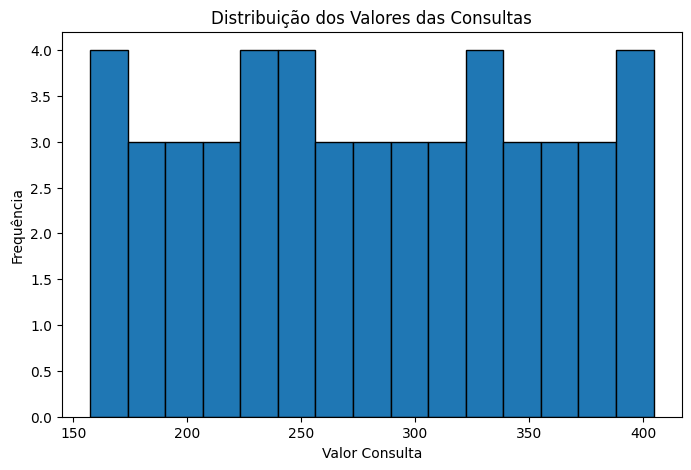

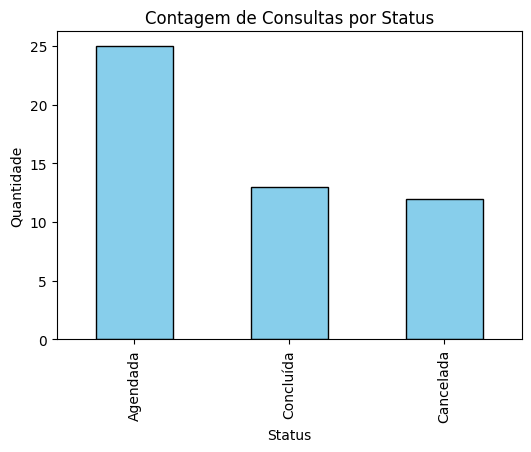

In [ ]:
# Visualização dos Dados
# Visualizações auxiliam na identificação de padrões e outliers. Utilizaremos o Matplotlib para criar gráficos simples.

import matplotlib.pyplot as plt

# Histograma para visualizar a distribuição dos valores de consulta
plt.figure(figsize=(8, 5))
plt.hist(df['VALOR_CONSULTA'], bins=15, edgecolor='black')
plt.title('Distribuição dos Valores das Consultas')
plt.xlabel('Valor Consulta')
plt.ylabel('Frequência')
plt.show()

# Gráfico de barras para a contagem por STATUS
plt.figure(figsize=(6, 4))
df['STATUS'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Contagem de Consultas por Status')
plt.xlabel('Status')
plt.ylabel('Quantidade')
plt.show()


Comentários:

* plt.figure: Configura o tamanho da figura para melhor visualização.

* plt.hist: Permite identificar a distribuição dos valores das consultas.

* df['STATUS'].value_counts().plot(kind='bar'): Cria um gráfico de barras que facilita a visualização da distribuição dos status.

In [14]:
# Pré-processamento dos Dados
# Antes de treinar um modelo, os dados precisam estar em um formato adequado.

# Exemplo: Converter a coluna VALOR_CONSULTA para float (removendo eventuais vírgulas ou caracteres indesejados)
df['VALOR_CONSULTA'] = df['VALOR_CONSULTA'].astype(str).str.replace(',', '.').astype(float)

# Verificar a existência de valores nulos e, se necessário, preencher ou remover registros
print(df.isnull().sum())

# Engenharia de atributos: Exemplo, extrair o mês da data de consulta, o que pode ser relevante para padrões sazonais
df['MES_CONSULTA'] = df['DATA_HORA_CONSULTA'].dt.month

# Visualiza as primeiras linhas após o pré-processamento
print(df.head())


ID                    0
DATA_HORA_CONSULTA    0
TIPO_PROCEDIMENTO     0
VALOR_CONSULTA        0
STATUS                0
PROFISSIONAL_OP_ID    0
MES_CONSULTA          0
dtype: int64
   ID DATA_HORA_CONSULTA TIPO_PROCEDIMENTO  VALOR_CONSULTA     STATUS  \
0   1         2024-09-20        Tipo Exame           157.3  Concluída   
1   2         2024-09-21     Tipo Consulta           164.6   Agendada   
2   3         2024-09-22  Tipo Radiografia           165.0   Agendada   
3   4         2024-09-23     Tipo Consulta           172.3  Cancelada   
4   5         2024-09-24        Tipo Exame           179.6  Concluída   

   PROFISSIONAL_OP_ID  MES_CONSULTA  
0                   1             9  
1                   2             9  
2                   3             9  
3                   4             9  
4                   5             9  


Comentários:

* Substituição de vírgula: Em alguns casos, valores numéricos podem vir com vírgula, sendo necessário convertê-los para o formato float.

* Tratamento de nulos: Fundamental para evitar problemas durante o treinamento do modelo.

* Engenharia de atributos: A extração de informações temporais pode revelar padrões importantes (por exemplo, variações sazonais).

In [ ]:
# Modelagem e Treinamento
# Como exemplo, vamos supor que queremos prever o status da consulta (por exemplo, diferenciar entre consultas que serão "Agendada" ou "Concluída"). Para isso, podemos utilizar um modelo de classificação como a Árvore de Decisão.
# Neste exemplo, faremos uma simplificação e consideraremos apenas um subconjunto de variáveis.

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Seleciona as features e o target (alvo) para o modelo
# Neste exemplo, usaremos VALOR_CONSULTA e MES_CONSULTA para prever o STATUS
# Note que em um cenário real, pode ser necessário converter o STATUS para valores numéricos (label encoding)
features = df[['VALOR_CONSULTA', 'MES_CONSULTA']]
target = df['STATUS']

# Realiza a codificação do target para valores numéricos (ex.: Agendada=0, Concluída=1, Cancelada=2)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
target_encoded = le.fit_transform(target)

# Divide os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(features, target_encoded, test_size=0.3, random_state=42)

# Inicializa e treina o modelo de Árvore de Decisão
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Faz previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avalia o modelo com métricas de acurácia e uma matriz de confusão
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))


Acurácia: 0.2

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.50      0.43      0.46         7
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         5

    accuracy                           0.20        15
   macro avg       0.17      0.14      0.15        15
weighted avg       0.23      0.20      0.22        15


Matriz de Confusão:
 [[3 1 3]
 [2 0 1]
 [1 4 0]]


Comentários:

* LabelEncoder: Converte categorias textuais em números para que o modelo possa processar.

* train_test_split: Separa os dados para treinamento e validação, garantindo que o modelo seja testado em dados não vistos.

* DecisionTreeClassifier: Um modelo simples e interpretável que serve bem como baseline.

* Métricas: A acurácia, o relatório de classificação e a matriz de confusão ajudam a avaliar o desempenho do modelo e identificar pontos de melhoria.

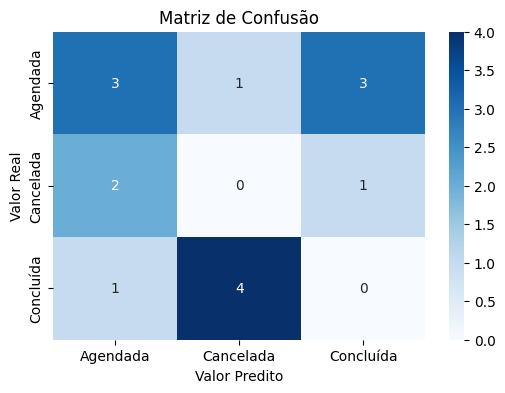

In [ ]:
# Avaliação e Validação
# Após o treinamento, é importante analisar os resultados e, se necessário, ajustar os parâmetros do modelo ou realizar novas transformações nos dados. Esta etapa pode incluir a criação de gráficos de avaliação.

# Exemplo de plot da matriz de confusão utilizando matplotlib
import seaborn as sns  # Neste exemplo, utilizamos o seaborn para facilitar a visualização, mas poderia ser substituído pelo matplotlib puro.

import numpy as np
import matplotlib.pyplot as plt

# Cria uma matriz de confusão a partir dos dados de teste
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Valor Predito')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão')
plt.show()


Comentários:

* Heatmap: Facilita a visualização dos erros de classificação e a identificação de classes que podem estar sendo confundidas.